# Assignment 2: Build a CNN for image recognition.

## Due Date:  March 30, 11:59PM

### Name: Ali Abdullah Ahmad


## Introduction:

1. In this assignment, you will build Convolutional Neural Network to classify CIFAR-10 Images.
2. You can directly load dataset from many deep learning packages.
3. You can use any deep learning packages such as pytorch, keras or tensorflow for this assignment.

## Requirements:

1. You need to load cifar 10 data and split the entire training dataset into training and validation.
2. You will implement a CNN model to classify cifar 10 images with provided structure.
3. You need to plot the training and validation accuracy or loss obtained from above step.
4. Then you can use tuned parameters to train using the entire training dataset.
5. You should report the testing accuracy using the model with complete data.
6. You may try to change the structure (e.g, add BN layer or dropout layer,...) and analyze your findings.

## Google Colab

- If you do not have GPU, the training of a CNN can be slow. Google Colab is a good option.

## Batch Normalization (BN)

### Background:

- Batch Normalization is a technique to speed up training and help make the model more stable.
- In simple words, batch normalization is just another network layer that gets inserted between a hidden layer and the next hidden layer. Its job is to take the outputs from the first hidden layer and normalize them before passing them on as the input of the next hidden layer.

- For more detailed information, you may refer to the original paper: https://arxiv.org/pdf/1502.03167.pdf.

### BN Algorithm:

- Input: Values of $x$ over a mini-batch: $\mathbf{B}$ = $\{x_1,..., x_m\};$
- Output: $\{y_i = BN_{\gamma,\beta}(x_i)\}$, $\gamma, \beta$ are learnable parameters

Normalization of the Input:
$$\mu_{\mathbf{B}} = \frac{1}{m}\sum_{i=1}^m x_i$$
$$\sigma_{\mathbf{B}}^2 = \frac{1}{m}\sum_{i=1}^m (x_i - \mu_{\mathbf{B}})^2$$
$$\hat{x_i} = \frac{x_i - \mu_{\mathbf{B}}}{\sqrt{\sigma_{\mathbf{B}}}^2 + \epsilon}$$
Re-scaling and Offsetting:
$$y_i = \gamma \hat{x_i} + \beta = BN_{\gamma,\beta}(x_i)$$


### Advantages of BN:
1. Improves gradient flow through the network.
2. Allows use of saturating nonlinearities and higher learning rates.
3. Makes weights easier to initialize.
4. Act as a form of regularization and may reduce the need for dropout.

### Implementation:

- The batch normalization layer has already been implemented in many packages. You may simply call the function to build the layer. For example: torch.nn.BatchNorm2d() using pytroch package, keras.layers.BatchNormalization() using keras package.
- The location of BN layer: Please make sure ```BatchNormalization``` is between a ```Conv```/```Dense``` layer and an ```activation``` layer.

## 1. Data preparation

### 1.1. Load data


shape of x_train: (50000, 32, 32, 3)
shape of y_train: (50000, 1)
shape of x_test: (10000, 32, 32, 3)
shape of y_test: (10000, 1)
number of classes: 10


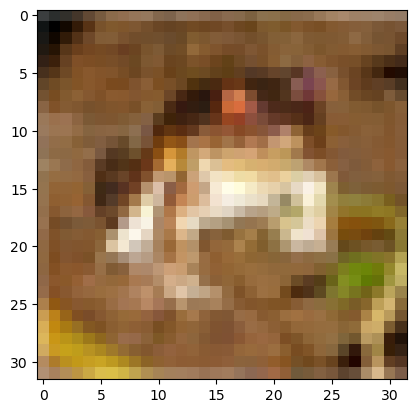

In [229]:
# Load Cifar-10 Data
# This is just an example, you may load dataset from other packages.
import keras
import numpy as np
from keras.datasets import cifar10
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

### If you can not load keras dataset, un-comment these two lines.
#import ssl
#ssl._create_default_https_context = ssl._create_unverified_context

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print('shape of x_train: ' + str(x_train.shape))
print('shape of y_train: ' + str(y_train.shape))
print('shape of x_test: ' + str(x_test.shape))
print('shape of y_test: ' + str(y_test.shape))
print('number of classes: ' + str(np.max(y_train) - np.min(y_train) + 1))

plt.imshow(x_train[0])
plt.show()

### 1.2. One-hot encode the labels (5 points)

In the input, a label is a scalar in $\{0, 1, \cdots , 9\}$. One-hot encode transform such a scalar to a $10$-dim vector. E.g., a scalar ```y_train[j]=3``` is transformed to the vector ```y_train_vec[j]=[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]```.

1. Implement a function ```to_one_hot``` that transforms an $n\times 1$ array to a $n\times 10$ matrix.

2. Apply the function to ```y_train``` and ```y_test```.

In [230]:
x_train_vec = x_train.reshape((50000, 32, 32, 3))/255.0
x_test_vec = x_test.reshape((10000, 32, 32, 3))/255.0
print("Shape of x_train_vec is :", x_train_vec.shape)
print("Shape of x_test_vec is :", x_test_vec.shape)

Shape of x_train_vec is : (50000, 32, 32, 3)
Shape of x_test_vec is : (10000, 32, 32, 3)


In [231]:
def to_one_hot(y, num_class=10):
    result = np.zeros((len(y),num_class))
    for i, label in enumerate(y):
        result[i,label]=1
    return result

y_train_vec = to_one_hot(y_train)
y_test_vec = to_one_hot(y_test)

print('Shape of y_train_vec: ' + str(y_train_vec.shape))
print('Shape of y_test_vec: ' + str(y_test_vec.shape))

print(y_train[0])
print(y_train_vec[0])

Shape of y_train_vec: (50000, 10)
Shape of y_test_vec: (10000, 10)
[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


#### Remark: the outputs should be
* Shape of y_train_vec: (50000, 10)
* Shape of y_test_vec: (10000, 10)
* [6]
* [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

### 1.3. Randomly partition the training set to training and validation sets (5 points)

Randomly partition the 50K training samples to 2 sets:
* a training set containing 40K samples: x_tr, y_tr
* a validation set containing 10K samples: x_val, y_val


In [232]:
random_indices = np.random.permutation(50000)
train_ran_ind = random_indices[:40000]
valid_ran_ind = random_indices[40000:]

x_tr = x_train_vec[train_ran_ind]
y_tr = y_train_vec[train_ran_ind]

x_val = x_train_vec[valid_ran_ind]
y_val = y_train_vec[valid_ran_ind]


print('Shape of x_tr: ' + str(x_tr.shape))
print('Shape of y_tr: ' + str(y_tr.shape))
print('Shape of x_val: ' + str(x_val.shape))
print('Shape of y_val: ' + str(y_val.shape))

Shape of x_tr: (40000, 32, 32, 3)
Shape of y_tr: (40000, 10)
Shape of x_val: (10000, 32, 32, 3)
Shape of y_val: (10000, 10)


## 2. Build a CNN and tune its hyper-parameters (50 points)

- Build a convolutional neural network model using the below structure:

- It should have a structure of: Conv - ReLU - Max Pool - ConV - ReLU - Max Pool - Dense - ReLU - Dense - Softmax

- In the graph 3@32x32 means the dimension of input image, 32@30x30 means it has 32 filters and the dimension now becomes 30x30 after the convolution.
- All convolutional layers (Conv) should have stride = 1 and no padding.
- Max Pooling has a pool size of 2 by 2.




![](https://drive.google.com/uc?export=view&id=16zjE3yjAmIjn2PLTZsxDTyxVdxHGTdnV)

- You may use the validation data to tune the hyper-parameters (e.g., learning rate, and optimization algorithm)
- Do NOT use test data for hyper-parameter tuning!!!
- Try to achieve a validation accuracy as high as possible.

In [233]:
# Build the model
from keras import layers
from keras.models import Sequential

model = models.Sequential()

In [234]:
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


c:\Users\abdul\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [235]:
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,204,682 (4.60 MB)

 Trainable params: 1,204,682 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

In [236]:
from keras.optimizers import RMSprop, Adadelta, Adam

model.compile(optimizer=RMSprop(learning_rate=0.0001),  
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [237]:
# Train the model and store model parameters/loss values

history = model.fit(x_tr,y_tr, epochs=50, batch_size=128, validation_data=(x_val,y_val))

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.2383 - loss: 2.1177 - val_accuracy: 0.3709 - val_loss: 1.7903
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.3942 - loss: 1.7183 - val_accuracy: 0.4201 - val_loss: 1.6280
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.4456 - loss: 1.5680 - val_accuracy: 0.4438 - val_loss: 1.5591
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.4761 - loss: 1.4771 - val_accuracy: 0.4875 - val_loss: 1.4490
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5080 - loss: 1.4031 - val_accuracy: 0.4850 - val_loss: 1.4506
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5309 - loss: 1.3428 - val_accuracy: 0.5150 - val_loss: 1.3813
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5426 - loss: 1.2999 - val_accuracy: 0.5489 - val_loss: 1.3137
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5541 - loss: 1.2695 - 

## 3. Plot the training and validation loss curve versus epochs. (5 points)

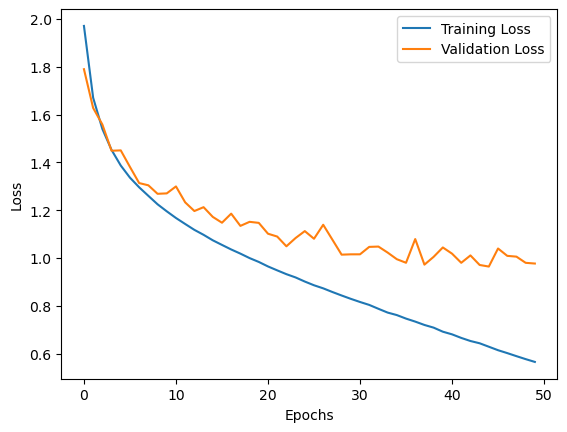

In [238]:
# Plot the loss curve

import matplotlib.pyplot as plt
%matplotlib inline
epoch = range(50)  # Match the number of epochs used in model.fit()
plt.plot(epoch, history.history['loss'], label='Training Loss')
plt.plot(epoch, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. Train (again) and evaluate the model (5 points)

- To this end, you have found the "best" hyper-parameters.
- Now, fix the hyper-parameters and train the network on the entire training set (all the 50K training samples)
- Evaluate your model on the test set.

### Train the model on the entire training set

Why? Previously, you used 40K samples for training; you wasted 10K samples for the sake of hyper-parameter tuning. Now you already know the hyper-parameters, so why not using all the 50K samples for training?

In [239]:
#<Compile your model again (using the same hyper-parameters you tuned above)>
from keras.optimizers import RMSprop, Adadelta, Adam

model.compile(optimizer=RMSprop(learning_rate=0.0001),  
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [240]:
#<Train your model on the entire training set (50K samples)>
history2 = model.fit(np.concatenate((x_tr, x_val)), np.concatenate((y_tr, y_val)), epochs=50, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.7873 - loss: 0.6411 - val_accuracy: 0.6816 - val_loss: 0.9578
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.7977 - loss: 0.6227 - val_accuracy: 0.6725 - val_loss: 0.9670
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8023 - loss: 0.5968 - val_accuracy: 0.7029 - val_loss: 0.8874
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8060 - loss: 0.5882 - val_accuracy: 0.7135 - val_loss: 0.8345
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8141 - loss: 0.5772 - val_accuracy: 0.7339 - val_loss: 0.7856
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8209 - loss: 0.5553 - val_accuracy: 0.7301 - val_loss: 0.7931
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8252 - loss: 0.5385 - val_accuracy: 0.7464 - val_loss: 0.7452
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8270 - loss: 0.5289 - 

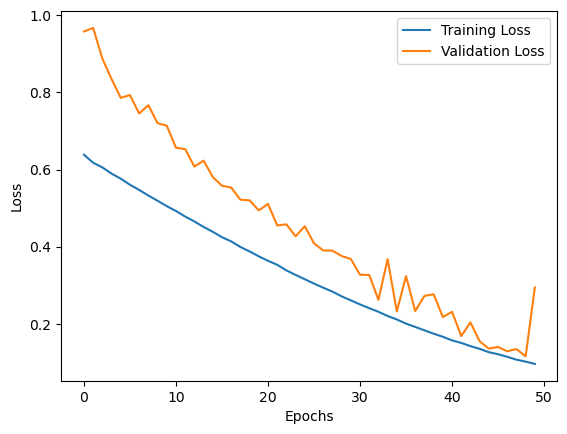

In [242]:
import matplotlib.pyplot as plt
%matplotlib inline
epoch = range(50)  # Match the number of epochs used in model.fit()
plt.plot(epoch, history2.history['loss'], label='Training Loss')
plt.plot(epoch, history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 5. Evaluate the model on the test set (5 points)

Do NOT used the test set until now. Make sure that your model parameters and hyper-parameters are independent of the test set.

In [ ]:
# Evaluate your model performance (testing accuracy) on testing data.

test_loss, test_accuracy = model.evaluate(x_test_vec, y_test_vec, verbose=2)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 - 1s - 4ms/step - accuracy: 0.6656 - loss: 1.5679
Test Accuracy: 66.56%


## 6. Building model with new structure (25 points)
- In this section, you can build your model with adding new layers (e.g, BN layer or dropout layer, ...)
- If you want to regularize a ```Conv/Dense layer```, you should place a ```Dropout layer``` before the ```Conv/Dense layer```.
- You can try to compare their loss curve and testing accuracy and analyze your findings.
- You need to try at lease two different structures.

# model with both BN and Dropout layer

In [251]:
model_with_BN_and_DropL = models.Sequential()

model_with_BN_and_DropL.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model_with_BN_and_DropL.add(layers.BatchNormalization()) #BN layer
model_with_BN_and_DropL.add(layers.MaxPooling2D(2, 2))
model_with_BN_and_DropL.add(layers.Dropout(0.25))     #Dropout layer

model_with_BN_and_DropL.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_with_BN_and_DropL.add(layers.BatchNormalization()) #BN layer
model_with_BN_and_DropL.add(layers.MaxPooling2D(2, 2))
model_with_BN_and_DropL.add(layers.Dropout(0.25))     #Dropout layer

model_with_BN_and_DropL.add(layers.Flatten())
model_with_BN_and_DropL.add(layers.Dense(512, activation='relu'))
model_with_BN_and_DropL.add(layers.BatchNormalization()) #BN layer
model_with_BN_and_DropL.add(layers.Dropout(0.5))      #Dropout layer
model_with_BN_and_DropL.add(layers.Dense(10, activation='softmax'))

model_with_BN_and_DropL.summary()

c:\Users\abdul\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_49 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,207,114 (4.60 MB)

 Trainable params: 1,205,898 (4.60 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [252]:
model_with_BN_and_DropL.compile(optimizer=RMSprop(learning_rate=0.0001),  
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [253]:
history_of_BN_and_DropL = model_with_BN_and_DropL.fit(np.concatenate((x_tr, x_val)), np.concatenate((y_tr, y_val)), epochs=50, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step - accuracy: 0.2631 - loss: 2.6062 - val_accuracy: 0.2299 - val_loss: 2.3860
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.4165 - loss: 1.8931 - val_accuracy: 0.5394 - val_loss: 1.3291
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.4685 - loss: 1.6422 - val_accuracy: 0.5679 - val_loss: 1.2582
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.5120 - loss: 1.4797 - val_accuracy: 0.6094 - val_loss: 1.1281
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.5354 - loss: 1.3798 - val_accuracy: 0.6449 - val_loss: 1.0352
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.5624 - loss: 1.2912 - val_accuracy: 0.6293 - val_loss: 1.0691
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.5837 - loss: 1.2109 - val_accuracy: 0.6727 - val_loss: 0.9519
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.6023 - loss: 1.1525 - 

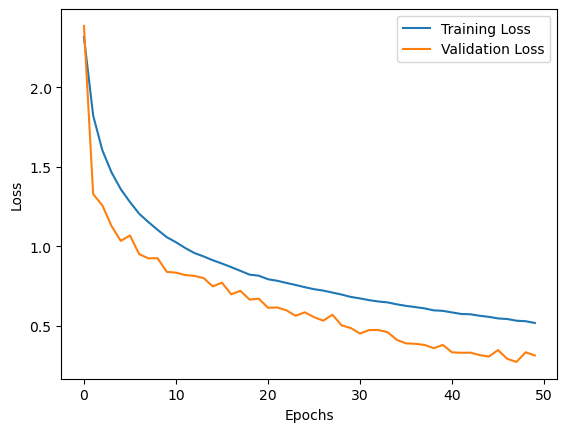

313/313 - 2s - 7ms/step - accuracy: 0.7508 - loss: 0.7520
Test Accuracy: 75.08%


In [258]:
epoch = range(50)  
plt.plot(epoch, history_of_BN_and_DropL.history['loss'], label='Training Loss')
plt.plot(epoch, history_of_BN_and_DropL.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


test_loss, test_accuracy = model_with_BN_and_DropL.evaluate(x_test_vec, y_test_vec, verbose=2)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# model with BN only

In [259]:
# Model with only Batch Normalization
model_with_BN = models.Sequential()

model_with_BN.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model_with_BN.add(layers.BatchNormalization())  # BN layer
model_with_BN.add(layers.MaxPooling2D(2, 2))

model_with_BN.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_with_BN.add(layers.BatchNormalization())  # BN layer
model_with_BN.add(layers.MaxPooling2D(2, 2))

model_with_BN.add(layers.Flatten())
model_with_BN.add(layers.Dense(512, activation='relu'))
model_with_BN.add(layers.BatchNormalization())  # BN layer
model_with_BN.add(layers.Dense(10, activation='softmax'))

model_with_BN.summary()

c:\Users\abdul\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_55 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,207,114 (4.60 MB)

 Trainable params: 1,205,898 (4.60 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [260]:
model_with_BN.compile(optimizer=RMSprop(learning_rate=0.0001),  
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [261]:
history_of_BN = model_with_BN.fit(np.concatenate((x_tr, x_val)), np.concatenate((y_tr, y_val)), epochs=50, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - accuracy: 0.4116 - loss: 1.7571 - val_accuracy: 0.3098 - val_loss: 1.9820
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.6211 - loss: 1.0901 - val_accuracy: 0.6902 - val_loss: 0.9136
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - accuracy: 0.6981 - loss: 0.8853 - val_accuracy: 0.7401 - val_loss: 0.7775
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.7488 - loss: 0.7515 - val_accuracy: 0.7878 - val_loss: 0.6538
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.7911 - loss: 0.6355 - val_accuracy: 0.8383 - val_loss: 0.5326
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.8274 - loss: 0.5498 - val_accuracy: 0.8705 - val_loss: 0.4568
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.8602 - loss: 0.4604 - val_accuracy: 0.8994 - val_loss: 0.3777
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.8953 - loss: 0.3823 

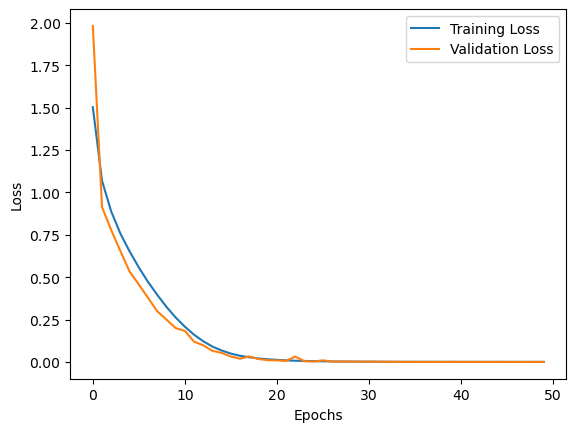

313/313 - 3s - 8ms/step - accuracy: 0.6775 - loss: 1.8454
Test Accuracy: 67.75%


In [262]:
epoch = range(50)  
plt.plot(epoch, history_of_BN.history['loss'], label='Training Loss')
plt.plot(epoch, history_of_BN.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


test_loss, test_accuracy = model_with_BN.evaluate(x_test_vec, y_test_vec, verbose=2)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Model with only Dropout

In [263]:
# Model with only Dropout
model_with_Dropout = models.Sequential()

model_with_Dropout.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model_with_Dropout.add(layers.MaxPooling2D(2, 2))
model_with_Dropout.add(layers.Dropout(0.25))  # Dropout layer

model_with_Dropout.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_with_Dropout.add(layers.MaxPooling2D(2, 2))
model_with_Dropout.add(layers.Dropout(0.25))  # Dropout layer

model_with_Dropout.add(layers.Flatten())
model_with_Dropout.add(layers.Dense(512, activation='relu'))
model_with_Dropout.add(layers.Dropout(0.5))  # Dropout layer
model_with_Dropout.add(layers.Dense(10, activation='softmax'))

model_with_Dropout.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_57 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,204,682 (4.60 MB)

 Trainable params: 1,204,682 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

In [264]:
model_with_Dropout.compile(optimizer=RMSprop(learning_rate=0.0001),  
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [265]:
history_of_DropL = model_with_Dropout.fit(np.concatenate((x_tr, x_val)), np.concatenate((y_tr, y_val)), epochs=50, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.1766 - loss: 2.2029 - val_accuracy: 0.3489 - val_loss: 1.9063
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.3367 - loss: 1.8443 - val_accuracy: 0.4174 - val_loss: 1.7094
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.3946 - loss: 1.6819 - val_accuracy: 0.4674 - val_loss: 1.5791
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4345 - loss: 1.5753 - val_accuracy: 0.4889 - val_loss: 1.4993
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4668 - loss: 1.4974 - val_accuracy: 0.5083 - val_loss: 1.4342
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4771 - loss: 1.4545 - val_accuracy: 0.5311 - val_loss: 1.3729
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4982 - loss: 1.4100 - val_accuracy: 0.5392 - val_loss: 1.3354
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5095 - loss: 1.3745 - 

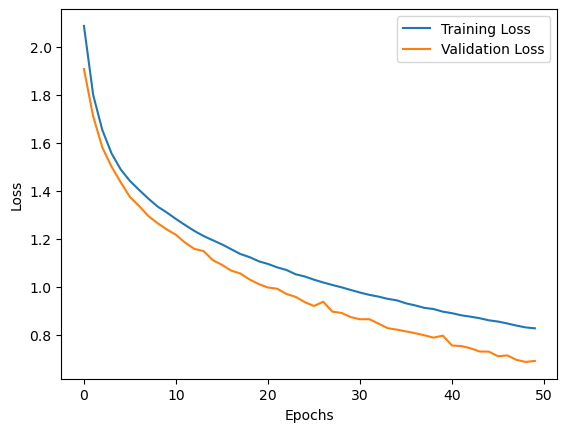

313/313 - 1s - 4ms/step - accuracy: 0.7144 - loss: 0.8338
Test Accuracy: 71.44%


In [266]:
epoch = range(50)  
plt.plot(epoch, history_of_DropL.history['loss'], label='Training Loss')
plt.plot(epoch, history_of_DropL.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


test_loss, test_accuracy = model_with_Dropout.evaluate(x_test_vec, y_test_vec, verbose=2)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

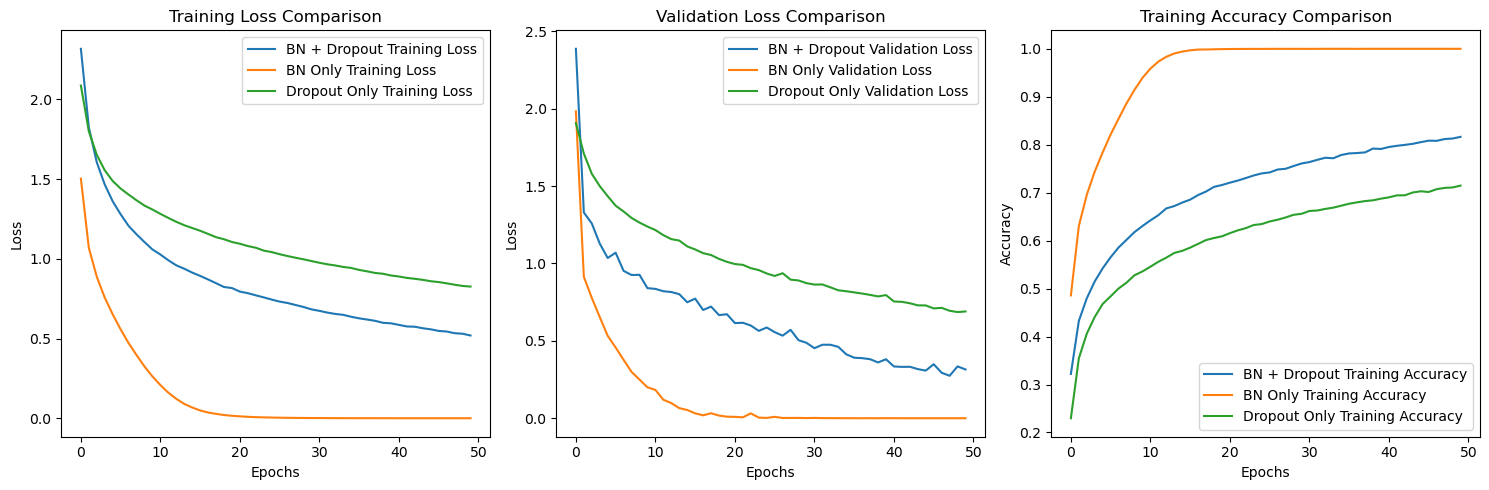

In [269]:
# Plot the loss curves for the latest three models
epoch = range(50)  # Match the number of epochs used in model.fit()

# Plot Training Loss
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(epoch, history_of_BN_and_DropL.history['loss'], label='BN + Dropout Training Loss')
plt.plot(epoch, history_of_BN.history['loss'], label='BN Only Training Loss')
plt.plot(epoch, history_of_DropL.history['loss'], label='Dropout Only Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Comparison')

# Plot Validation Loss
plt.subplot(1, 3, 2)
plt.plot(epoch, history_of_BN_and_DropL.history['val_loss'], label='BN + Dropout Validation Loss')
plt.plot(epoch, history_of_BN.history['val_loss'], label='BN Only Validation Loss')
plt.plot(epoch, history_of_DropL.history['val_loss'], label='Dropout Only Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Validation Loss Comparison')

# Plot Test Accuracy
plt.subplot(1, 3, 3)
plt.plot(epoch, history_of_BN_and_DropL.history['accuracy'], label='BN + Dropout Training Accuracy')
plt.plot(epoch, history_of_BN.history['accuracy'], label='BN Only Training Accuracy')
plt.plot(epoch, history_of_DropL.history['accuracy'], label='Dropout Only Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Comparison')

plt.tight_layout()
plt.show()